# CB Green Finance & Low Carbon Heating Analysis

## 📋 Notebook Overview

**Purpose**: This notebook analyzes green finance companies from Crunchbase data using a two-stage filtering approach to identify heating-specific companies within the broader green finance ecosystem.

**Main Objectives**:
- **Stage 1**: Apply `green_finance_simple` filter to identify broadly relevant green finance companies
- **Stage 2**: Apply `low_carbon_heating` filter to Stage 1 results to focus on heating-specific companies  
- Generate comprehensive analysis including funding trends, geographic distribution, and investment patterns
- Export data to Google Sheets for sharing and further analysis

**Key Features**:
- Two-stage progressive filtering with LLM validation
- Multi-dimensional analysis (time series, growth rates, funding breakdowns)
- Geographic distribution analysis with EU/UK/Other grouping
- Automated Google Sheets export with formatting
- Investment stage mapping (early/growth/late/other)

**Expected Results**: 
- Green Finance Simple: ~100-200 companies
- Low Carbon Heating: ~15-30 companies (typically 10-25% of green finance)

---

In [2]:
from discovery_utils.getters import crunchbase
from discovery_utils.utils import search
from discovery_utils.utils.llm.batch_check import LLMProcessor, generate_relevance_check_system_message
from discovery_mission_radar import PROJECT_DIR
from discovery_utils.utils.io import remap_dict
from pathlib import Path
import pandas as pd

/Users/karlis.kanders/Code/discovery_mission_radar/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-07-31 15:38:21,095 - datasets - INFO - PyTorch version 2.4.1 available.


## ⚙️ Technical Requirements

**Prerequisites**:
- `discovery_utils` and `discovery_mission_radar` packages installed
- AWS credentials configured for Crunchbase S3 access
- OpenAI API key for LLM relevance checking
- Google Sheets API service account credentials

**Key Configuration Parameters**:
- `SCORE_THRESHOLD = 0.3` - Minimum relevance score for search results (lower = more results)
- `INCLUDE_*_STAGE` flags - Control which funding stages to include in analysis
- `primary_config = "green_finance_simple"` - First stage filter
- `secondary_config = "low_carbon_heating"` - Second stage filter

**Required Files**:
- `config_green_finance_simple.yaml` - Defines search terms for broad green finance
- `config_low_carbon_heating.yaml` - Defines search terms for heating-specific companies
- Vector database in `tmp/vector_db/` for semantic search

**Expected Runtime**:
- Quick run (existing data): 2-3 minutes
- Full run with LLM processing: 20-30 minutes
- Memory usage: ~2GB peak during analysis

---

## 1. Setup and Imports

# Crunchbase Green Finance Analysis

This notebook analyzes green finance companies using Crunchbase data with a two-stage filtering approach:

1. **Stage 1**: Apply `green_finance_simple` filter to identify broadly relevant green finance companies
2. **Stage 2**: Apply `low_carbon_heating` filter to the Stage 1 results to focus on heating-specific companies

## Outputs Generated

The notebook creates organized outputs in the following structure:

```
data/green_finance/cb/
├── green_finance_simple/             # Stage 1 results
│   ├── raw/                          # Raw search results (pre-LLM filtering)
│   │   ├── relevant_green_finance_simple.csv
│   │   └── llm_check_MS_green_finance_simple.jsonl
│   ├── filtered/                     # LLM-filtered results
│   │   ├── relevant_green_finance_simple_llm_filtered.csv
│   │   └── relevant_green_finance_simple_rejected.csv
│   └── produce_stats/                # Analysis outputs
│       ├── charts/                   # PNG charts
│       ├── ts_*.csv, growth_rates_*.csv  # Individual datasets
│       └── all_*.csv                 # Combined datasets
└── low_carbon_heating/               # Stage 2 results
    ├── raw/                          # Raw search results (pre-LLM filtering)
    │   ├── relevant_low_carbon_heating.csv
    │   └── llm_check_MS_low_carbon_heating.jsonl
    ├── filtered/                     # LLM-filtered results
    │   ├── relevant_low_carbon_heating_llm_filtered.csv
    │   └── relevant_low_carbon_heating_rejected.csv
    └── produce_stats/                # Analysis outputs
        ├── charts/                   # PNG charts
        ├── ts_*.csv, growth_rates_*.csv  # Individual datasets
        └── all_*.csv                 # Combined datasets
```

## Directory Structure

- **raw/**: Contains initial search results and LLM processing files before filtering
- **filtered/**: Contains LLM-approved and rejected results after relevance checking  
- **produce_stats/**: Contains all analysis outputs, charts, and aggregated data files

## Usage Notes

- **Quick Run**: If filtered CSV files already exist, you can skip the LLM filtering sections
- **Charts**: All charts saved as PNG files in respective `produce_stats/charts/` directories
- **Data**: Individual CSVs for specific analysis, "all_*.csv" files for complete datasets per config
- **Clean Start**: Directory structure is created automatically with proper subdirectory organization

In [ ]:
OUTPUT_DIR = PROJECT_DIR / 'data/green_finance/cb/'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
VECTOR_DB_DIR = PROJECT_DIR / 'tmp/vector_db/'
VECTOR_DB_DIR.mkdir(parents=True, exist_ok=True)
SCORE_THRESHOLD = 0.3

## 2. Configuration

In [4]:
CB = crunchbase.CrunchbaseGetter(vector_db_path=VECTOR_DB_DIR)

# Configuration flags for funding analysis
INCLUDE_LATE_STAGE = True  # Set to True to include late-stage funding, False for early-stage only
INCLUDE_GROWTH_STAGE = True  # Set to True to include growth-stage funding
INCLUDE_OTHER_STAGE = True  # Set to True to include other funding stages

investment_stages = {
    'early_stage': ['pre_seed', 'seed', 'angel', 'series_a', 'series_b', 'convertible_note',
                   'equity_crowdfunding', 'product_crowdfunding', 'non_equity_assistance', 'initial_coin_offering'],
    'growth_stage': ['series_c', 'series_d', 'series_e', 'series_f', 'series_g', 'series_h', 'series_i', 'series_j'],
    'late_stage': ['private_equity', 'post_ipo_equity', 'post_ipo_debt', 'post_ipo_secondary', 'secondary_market'],
    'other': ['corporate_round', 'debt_financing', 'grant', 'series_unknown', 'undisclosed']
}

# Build funding round types based on configuration
FUNDING_ROUND_TYPES = investment_stages['early_stage'].copy()
if INCLUDE_GROWTH_STAGE:
    FUNDING_ROUND_TYPES.extend(investment_stages['growth_stage'])
if INCLUDE_LATE_STAGE:
    FUNDING_ROUND_TYPES.extend(investment_stages['late_stage'])
if INCLUDE_OTHER_STAGE:
    FUNDING_ROUND_TYPES.extend(investment_stages['other'])

# Create descriptive string for analysis
stage_descriptions = ['Early-stage']
if INCLUDE_GROWTH_STAGE:
    stage_descriptions.append('Growth-stage')
if INCLUDE_LATE_STAGE:
    stage_descriptions.append('Late-stage')
if INCLUDE_OTHER_STAGE:
    stage_descriptions.append('Other')
FUNDING_ROUND_TYPES_STR = ', '.join(stage_descriptions) + ' funding'

print(f"Analysis will include: {FUNDING_ROUND_TYPES_STR}")
print(f"Funding round types: {len(FUNDING_ROUND_TYPES)} types")

investment_type_to_stage = remap_dict(investment_stages)

2025-07-31 15:38:22,450 - discovery_utils.getters.crunchbase - INFO - Checking for latest version of data in S3 bucket: discovery-iss
2025-07-31 15:38:22,573 - discovery_utils.getters.crunchbase - INFO - Latest Crunchbase version found: Crunchbase_2025-07-28
Analysis will include: Early-stage, Growth-stage, Late-stage, Other funding
Funding round types: 28 types


In [ ]:
# define both configs
primary_config = "green_finance_simple"
secondary_config = "low_carbon_heating"

# Create config directory structure
CONFIG_DIR = PROJECT_DIR / 'discovery_mission_radar/notebooks/lch_green_finance/cb/config/'
CONFIG_DIR.mkdir(parents=True, exist_ok=True)

config_files = {
    primary_config: CONFIG_DIR / f"config_{primary_config}.yaml",
    secondary_config: CONFIG_DIR / f"config_{secondary_config}.yaml",
}

# Create config-specific directories with raw/ and filtered/ subdirectories
for config_name in [primary_config, secondary_config]:
    config_dir = OUTPUT_DIR / config_name
    config_dir.mkdir(exist_ok=True)
    
    raw_dir = config_dir / "raw"
    filtered_dir = config_dir / "filtered"
    raw_dir.mkdir(exist_ok=True)
    filtered_dir.mkdir(exist_ok=True)

# Check if processed data already exists
gf_csv_path = OUTPUT_DIR / primary_config / "filtered" / f"relevant_{primary_config}_llm_filtered.csv"
lc_csv_path = OUTPUT_DIR / secondary_config / "filtered" / f"relevant_{secondary_config}_llm_filtered.csv"

if gf_csv_path.exists():
    print(f"✓ Found existing {primary_config} filtered data. Loading from file...")
    df_primary_filtered = pd.read_csv(gf_csv_path)
    print(f"Loaded {len(df_primary_filtered)} {primary_config} companies")
else:
    print(f"⚠️  No existing {primary_config} data found. Running full filtering process...")
    
    # -- STEP 1: primary green finance filter --
    
    # run keyword+vector search
    Search1 = search.SearchDataset(CB, CB.organisations_enriched, config_files[primary_config])
    df1 = (
        Search1.do_search()
               .merge(CB.descriptions[['id','description']], on='id', how='left')
               .fillna({'description':'','short_description':'','name':''})
               .assign(text=lambda d: d['name'] + '. ' + d['short_description'] + ' ' + d['description'])
    )
    relevant_gf = df1.query(f"_score_avg > {SCORE_THRESHOLD}")
    gf_csv_path_temp = OUTPUT_DIR / primary_config / "raw" / f"relevant_{primary_config}.csv"
    gf_jsonl_path = OUTPUT_DIR / primary_config / "raw" / f"llm_check_MS_{primary_config}.jsonl"
    relevant_gf.to_csv(gf_csv_path_temp, index=False)

    # LLM‐based relevance check
    print(config_files[primary_config])
    sys1 = generate_relevance_check_system_message(str(config_files[primary_config]))
    proc1 = LLMProcessor(
        output_path=str(gf_jsonl_path),
        system_message=sys1,
        session_name="mission_studio",
        output_fields=[{"name":"is_relevant","type":"str","description":"yes or no"}]
    )
    await proc1.run(dict(zip(relevant_gf['id'], relevant_gf['text'])), batch_size=15, sleep_time=0.5)
    
    # Merge CSV and JSONL, filter for relevant entries, save filtered CSV
    df_csv = pd.read_csv(gf_csv_path_temp)
    df_jsonl = pd.read_json(gf_jsonl_path, lines=True)
    merged = df_csv.merge(df_jsonl[['id', 'is_relevant']], on='id', how='left')
    filtered = merged[merged['is_relevant'].str.lower() == 'yes']
    filtered.to_csv(gf_csv_path, index=False)
    rejected = merged[merged['is_relevant'].str.lower() == 'no']
    rejected.to_csv(OUTPUT_DIR / primary_config / "filtered" / f"relevant_{primary_config}_rejected.csv", index=False)
    print(f"Filtered {len(filtered)} relevant entries out of {len(df_csv)} total.")
    print(f"Filtered {len(rejected)} rejected entries out of {len(df_csv)} total.")
    
    # load the LLM‐filtered CSV
    df_primary_filtered = filtered.copy()

if lc_csv_path.exists():
    print(f"✓ Found existing {secondary_config} filtered data. Loading from file...")
    df_secondary_filtered = pd.read_csv(lc_csv_path)
    print(f"Loaded {len(df_secondary_filtered)} {secondary_config} companies")
else:
    print(f"⚠️  No existing {secondary_config} data found. Running filtering on {primary_config} subset...")
    
    # -- STEP 2: secondary low_carbon filter on the subset --
    
    # narrow CB.organisations_enriched to only first‐stage IDs
    subset = CB.organisations_enriched[CB.organisations_enriched['id'].isin(df_primary_filtered['id'])]
    
    Search2 = search.SearchDataset(CB, subset, config_files[secondary_config])
    df2 = (
        Search2.do_search()
               .merge(CB.descriptions[['id','description']], on='id', how='left')
               .fillna({'description':'','short_description':'','name':''})
               .assign(text=lambda d: d['name'] + '. ' + d['short_description'] + ' ' + d['description'])
    )
    relevant_lc = df2.query(f"_score_avg > {SCORE_THRESHOLD}")
    lc_csv_path_temp = OUTPUT_DIR / secondary_config / "raw" / f"relevant_{secondary_config}.csv"
    lc_jsonl_path = OUTPUT_DIR / secondary_config / "raw" / f"llm_check_MS_{secondary_config}.jsonl"
    relevant_lc.to_csv(lc_csv_path_temp, index=False)


    # LLM‐based relevance check for low carbon
    sys2 = generate_relevance_check_system_message(str(config_files[secondary_config]))
    proc2 = LLMProcessor(
        output_path=str(lc_jsonl_path),
        system_message=sys2,
        session_name="mission_studio",
        output_fields=[{"name":"is_relevant","type":"str","description":"yes or no"}]
    )
    await proc2.run(dict(zip(relevant_lc['id'], relevant_lc['text'])), batch_size=15, sleep_time=0.5)
    # Merge CSV and JSONL, filter for relevant entries, save filtered CSV
    df_csv2 = pd.read_csv(lc_csv_path_temp)
    df_jsonl2 = pd.read_json(lc_jsonl_path, lines=True)
    merged2 = df_csv2.merge(df_jsonl2[['id', 'is_relevant']], on='id', how='left')
    filtered2 = merged2[merged2['is_relevant'].str.lower() == 'yes']
    filtered2.to_csv(lc_csv_path, index=False)
    rejected2 = merged2[merged2['is_relevant'].str.lower() == 'no']
    rejected2.to_csv(OUTPUT_DIR / secondary_config / "filtered" / f"relevant_{secondary_config}_rejected.csv", index=False)
    print(f"Filtered {len(filtered2)} relevant entries out of {len(df_csv2)} total.")
    print(f"Filtered {len(rejected2)} rejected entries out of {len(df_csv2)} total.")
    
    df_secondary_filtered = filtered2.copy()

print(f"\n🎯 Data Summary:")
print(f"Green Finance Simple: {len(df_primary_filtered)} companies")
print(f"Low Carbon Heating: {len(df_secondary_filtered)} companies")
print(f"Filtering ratio: {len(df_secondary_filtered)/len(df_primary_filtered)*100:.1f}% of green finance companies are heating-focused")

✓ Found existing green_finance_simple filtered data. Loading from file...
Loaded 172 green_finance_simple companies
✓ Found existing low_carbon_heating filtered data. Loading from file...
Loaded 25 low_carbon_heating companies

🎯 Data Summary:
Green Finance Simple: 172 companies
Low Carbon Heating: 25 companies
Filtering ratio: 14.5% of green finance companies are heating-focused


## 🚀 Usage Instructions

### Quick Start
1. **For existing data**: If filtered CSV files exist, the notebook will automatically load them and skip LLM processing
2. **For fresh analysis**: Delete the `filtered/` directories to force reprocessing with LLM validation
3. **Run all cells**: Execute sequentially - the notebook handles data flow automatically

### Key Parameters to Modify

```python
# Adjust filtering sensitivity
SCORE_THRESHOLD = 0.2  # Lower = more results, 0.4 = more selective

# Focus on specific funding stages  
INCLUDE_LATE_STAGE = False  # Exclude late-stage funding
INCLUDE_GROWTH_STAGE = False  # Focus only on early-stage

# Limit Google Sheets upload
SHEET_TO_UPDATE = "crunchbase_companies"  # Upload specific sheet only
```

### Output Structure
- **Raw data**: `data/green_finance/cb/{config}/raw/` - Pre-LLM filtering results
- **Filtered data**: `data/green_finance/cb/{config}/filtered/` - LLM-approved companies  
- **Analysis**: `data/green_finance/cb/{config}/produce_stats/` - Charts, CSVs, statistics
- **Google Sheets**: Automatically uploaded with formatting applied

### Before Running
- Ensure config YAML files exist in `config/` directory
- Update Google Sheet IDs in upload sections if needed
- Verify sufficient disk space (~200MB for outputs)

---

## 3. Analysis: Green Finance Simple (Stage 1)

This section analyzes the broader green finance dataset after the first filtering stage.

In [6]:
from discovery_utils.utils import (
    analysis_crunchbase,
    analysis,
    charts,
)

# FUNDING_ROUND_TYPES and FUNDING_ROUND_TYPES_STR are now defined in the configuration cell above
print(f"Using funding stages: {FUNDING_ROUND_TYPES_STR}")
print(f"Total funding round types: {len(FUNDING_ROUND_TYPES)}")

Using funding stages: Early-stage, Growth-stage, Late-stage, Other funding
Total funding round types: 28


In [7]:
cols_funding_rounds = [
    "funding_round_name", 
    "org_name",
    "theme",
    "cb_url",
    "country_code", 
    "region_nesta",
    "region",
    "city",
    "year",
    "announced_on",
    "investment_type", 
    "investment_stage",
    "raised_amount_gbp",
    "raised_amount_usd",
    "raised_amount", 
    "raised_amount_currency_code",
    "post_money_valuation_usd", 
    "post_money_valuation",
    "post_money_valuation_currency_code", 
    "investor_name",
]

In [8]:
import altair as alt

cols_companies = [
    "name", 
    "short_description", 
    "founded_on", 
    'created_at',    
    "cb_url", 
    "homepage_url", 
    "ai_relevance_check",  # Uncommented - this should be available after merge and rename
    "theme",               # Added - this gets added with .assign(theme=config_name)
    'mission_labels',
    'topic_labels',
    "rank", 
    "country_code", 
    'region_nesta',
    "region", 
    "city", 
    "status", 
    "category_list", 
    "closed_on", 
    "employee_count", 
    "email", 
    "phone", 
    "facebook_url", 
    "linkedin_url", 
    "twitter_url", 
    "logo_url",   
    "num_exits", 
    "num_funding_rounds", 
    "last_funding_on", 
    "investment_funding_gbp", 
    "num_investment_rounds", 
    "grant_funding_gbp", 
    "num_grants", 
    "total_funding_gbp", 
    "smart_money", 
    "_score_keywords",
    "_score_vectors",
    "_score_avg",
]

def aggregate_by_funding_stages(funding_rounds_df):
    """
    Aggregate funding rounds by funding stage (early/growth/late) instead of individual investment types.
    Similar to analysis_crunchbase.aggregate_by_funding_round_types but groups by stage.
    """
    # Add investment stage column using existing mapping
    funding_rounds_with_stage = funding_rounds_df.copy()
    funding_rounds_with_stage['investment_stage'] = funding_rounds_with_stage['investment_type'].map(investment_type_to_stage)
    
    # Group by year and investment stage (instead of investment type)
    aggregated = (
        funding_rounds_with_stage
        .groupby(['year', 'investment_stage'])
        .agg({
            'raised_amount_gbp': 'sum',
            'funding_round_id': 'count'
        })
        .reset_index()
        .rename(columns={
            'funding_round_id': 'num_funding_rounds',
            'raised_amount_gbp': 'total_amount'
        })
    )
    
    # Convert to millions for easier reading
    aggregated['total_amount_millions'] = aggregated['total_amount']
    
    return aggregated

def chart_funding_stages(aggregated_funding_stages_df, chart_title=None):
    """
    Chart funding amounts by stage (early/growth/late) over time.
    Similar to analysis_crunchbase.chart_investment_types but for stages.
    """
    chart = alt.Chart(aggregated_funding_stages_df).mark_bar().encode(
        x=alt.X('year:O', title='Year'),
        y=alt.Y('total_amount_millions:Q', title='Total Amount (£ billions)'),
        color=alt.Color('investment_stage:N', title='Funding Stage'),
        tooltip=['year:O', 'investment_stage:N', 'total_amount_millions:Q', 'num_funding_rounds:Q']
    ).properties(
        width=600,
        height=400,
        title=chart_title or 'Funding Amounts by Stage Over Time'
    )
    
    return chart

def chart_funding_stages_counts(aggregated_funding_stages_df, chart_title=None):
    """
    Chart number of funding rounds by stage (early/growth/late) over time.
    Similar to analysis_crunchbase.chart_investment_types_counts but for stages.
    """
    chart = alt.Chart(aggregated_funding_stages_df).mark_bar().encode(
        x=alt.X('year:O', title='Year'),
        y=alt.Y('num_funding_rounds:Q', title='Number of Funding Rounds'),
        color=alt.Color('investment_stage:N', title='Funding Stage'),
        tooltip=['year:O', 'investment_stage:N', 'num_funding_rounds:Q', 'total_amount_millions:Q']
    ).properties(
        width=600,
        height=400,
        title=chart_title or 'Number of Funding Rounds by Stage Over Time'
    )
    
    return chart

In [9]:
configs = ["green_finance_simple", "low_carbon_heating"]

In [10]:
def produce_stats(CB, matching_ids: list[str], category_name: str, config_output_dir: Path) -> tuple:
    """ Produce stats for the companies and output charts """
    # Create produce_stats subdirectory and charts subdirectory for this config
    produce_stats_dir = config_output_dir / "produce_stats"
    charts_dir = produce_stats_dir / "charts"
    chart_csvs_dir = produce_stats_dir / "chart_csvs"
    charts_dir.mkdir(parents=True, exist_ok=True)
    chart_csvs_dir.mkdir(parents=True, exist_ok=True)
    
    # Check companies by querying ids
    matchings_orgs_df = CB.organisations_enriched.query("id in @matching_ids")

    # Get the funding rounds for the matching companies
    funding_rounds_df = (
        CB.select_funding_rounds(org_ids=matching_ids, funding_round_types=FUNDING_ROUND_TYPES)
    )

    # organise investors by each funding round
    investors_df = (
        CB.funding_rounds_enriched
        .query("funding_round_id in @funding_rounds_df.funding_round_id")
        .groupby("funding_round_id")
        .agg(investor_name=("investor_name", list))
        .reset_index()
    )

    funding_rounds_df = (
        funding_rounds_df
        .drop(columns=["investor_name"])
        .merge(investors_df, on="funding_round_id", how="left").drop_duplicates("funding_round_id", keep="first")
    )

    # generate basic time series
    ts_df = analysis_crunchbase.get_timeseries(
        matchings_orgs_df, 
        funding_rounds_df, 
        period='year', 
        min_year=2014, 
        max_year=2025
    )
    
    # Fill in missing years with zeros for better chart visualization
    # Need to convert year to datetime for imputation, then back to year
    ts_df_for_imputation = ts_df.copy()
    ts_df_for_imputation['year_datetime'] = pd.to_datetime(ts_df_for_imputation['year'], format='%Y')
    
    # Apply imputation using the datetime column
    ts_df_imputed = analysis.impute_empty_periods(
        ts_df_for_imputation.drop('year', axis=1), 
        time_period_col='year_datetime', 
        period='Y',  # 'Y' for annual/yearly data
        min_year=2014, 
        max_year=2025
    )
    
    # Convert back to integer year for downstream functions
    ts_df = ts_df_imputed.copy()
    ts_df['year'] = ts_df['year_datetime'].dt.year
    ts_df = ts_df.drop('year_datetime', axis=1)
    
    growth_rates = analysis.smoothed_growth(ts_df, year_start=2020, year_end=2024)
    growth_rates_df = pd.DataFrame(
        growth_rates, columns=[category_name]
    ).T.reset_index().rename(columns={'index': 'theme'})  

    # Breakdown of deal types (detailed)
    aggregated_funding_types_df = analysis_crunchbase.aggregate_by_funding_round_types(funding_rounds_df)
    
    # Breakdown by funding stages (grouped)
    aggregated_funding_stages_df = aggregate_by_funding_stages(funding_rounds_df)
    
    # Fill in missing years for funding stages data too
    # For grouped data, we need to apply imputation per group
    imputed_stages_list = []
    for stage in aggregated_funding_stages_df['investment_stage'].unique():
        stage_data = aggregated_funding_stages_df[aggregated_funding_stages_df['investment_stage'] == stage].copy()
        
        # Convert year to datetime for imputation
        stage_data['year_datetime'] = pd.to_datetime(stage_data['year'], format='%Y')
        stage_data_for_imputation = stage_data.drop('year', axis=1)
        
        # Apply imputation
        stage_imputed = analysis.impute_empty_periods(
            stage_data_for_imputation,
            time_period_col='year_datetime',
            period='Y',
            min_year=2014,
            max_year=2025
        )
        
        # Convert back to integer year and re-add the stage column
        stage_imputed['year'] = stage_imputed['year_datetime'].dt.year
        stage_imputed = stage_imputed.drop('year_datetime', axis=1)
        stage_imputed['investment_stage'] = stage
        imputed_stages_list.append(stage_imputed)
    
    # Combine all imputed stage data
    if imputed_stages_list:
        aggregated_funding_stages_df = pd.concat(imputed_stages_list, ignore_index=True)

    # IPOs and acquisitions
    ipos_df = CB.ipos.query("org_id in @matching_ids")
    acquisitions_df = CB.acquisitions.query("acquiree_id in @matching_ids")

    # EXPORT CHART DATA AS CSVs
    # 1. Time series chart data
    ts_chart_data = ts_df[['year', 'raised_amount_gbp_total', 'n_orgs_founded']].copy()
    ts_chart_data['raised_amount_millions'] = ts_chart_data['raised_amount_gbp_total'] 
    ts_chart_data.to_csv(chart_csvs_dir / f"time_series_chart_data_{category_name}.csv", index=False)
    
    # 2. Investment types chart data  
    investment_types_chart_data = aggregated_funding_types_df.copy()
    #investment_types_chart_data['total_amount_millions'] = investment_types_chart_data['total_amount_millions']
    investment_types_chart_data.to_csv(chart_csvs_dir / f"investment_types_chart_data_{category_name}.csv", index=False)
    
    # 3. Investment stages chart data
    aggregated_funding_stages_df.to_csv(chart_csvs_dir / f"investment_stages_chart_data_{category_name}.csv", index=False)

    # Note: CSV files are now saved in the main analysis cell to avoid duplication
    # Only save the new funding stages data that's not duplicated elsewhere
    aggregated_funding_stages_df.to_csv(produce_stats_dir / f"funding_stages_{category_name}.csv", index=False)
        
    # Fig variables
    prefix = f"{charts_dir}/{category_name}_"
    _scale = 2

    # Investment amounts (total)
    fig = charts.ts_bar(
        ts_df,
        variable='raised_amount_gbp_total',
        variable_title="Raised amount, £ millions",
        category_column="_category",
    )
    fig = charts.configure_plots(fig, chart_title=f"Funding raised over time for {category_name}")
    fig.save(f"{prefix}raised_amount.png", scale_factor=_scale)

    # Number of companies
    fig = charts.ts_bar(
        ts_df,
        variable='n_orgs_founded',
        variable_title="Number of companies founded",
        category_column="_category",
    )
    fig = charts.configure_plots(fig, chart_title=f"Number of founded {category_name} companies")
    fig.save(f"{prefix}no_of_companies.png", scale_factor=_scale)    

    # Investment amounts (by detailed type)
    investment_types_fig = analysis_crunchbase.chart_investment_types(aggregated_funding_types_df)
    investment_types_fig = charts.configure_plots(
        investment_types_fig, chart_title=f"Breakdown of investment types for {category_name}"
    )
    investment_types_fig.save(f"{prefix}investment_types.png", scale_factor=_scale)

    # Investment counts (by detailed type)
    investment_types_counts_fig = analysis_crunchbase.chart_investment_types_counts(aggregated_funding_types_df)
    investment_types_counts_fig = charts.configure_plots(
        investment_types_counts_fig, chart_title=f"Number of investments by type for {category_name}"
    )
    investment_types_counts_fig.save(f"{prefix}investment_types_counts.png", scale_factor=_scale)

    # NEW: Investment amounts (by funding stage - grouped)
    funding_stages_fig = chart_funding_stages(
        aggregated_funding_stages_df, 
        chart_title=f"Funding amounts by stage for {category_name}"
    )
    funding_stages_fig = charts.configure_plots(funding_stages_fig)
    funding_stages_fig.save(f"{prefix}funding_stages.png", scale_factor=_scale)

    # NEW: Investment counts (by funding stage - grouped)
    funding_stages_counts_fig = chart_funding_stages_counts(
        aggregated_funding_stages_df, 
        chart_title=f"Number of investments by stage for {category_name}"
    )
    funding_stages_counts_fig = charts.configure_plots(funding_stages_counts_fig)
    funding_stages_counts_fig.save(f"{prefix}funding_stages_counts.png", scale_factor=_scale)

    return ts_df, growth_rates_df, ipos_df, acquisitions_df, matchings_orgs_df, funding_rounds_df

In [14]:
orgs_to_include_manually = {
    "green_finance_simple": [
        "f5facd3b-0b43-48cd-9f88-b3dedd10540d", # Bees & Bears
        "4bd36dae-06ba-4438-88ba-2bd40fe4e1f1", # CapeZero
        "dd24db62-355f-44f1-8358-e3e9b7fbf099", # SolarAfrica
        "c7f85084-9c8f-5be6-746a-10b3d893092c", # Palmetto
    ],
    "low_carbon_heating": [
        "f5facd3b-0b43-48cd-9f88-b3dedd10540d", # Bees & Bears
        "c7f85084-9c8f-5be6-746a-10b3d893092c", # Palmetto
    ],
}

In [15]:
# Create cb directory for Crunchbase analysis outputs
CB_OUTPUT_DIR = OUTPUT_DIR

for config_name in configs:
    print(f"Processing {config_name}")
    
    # Create separate directory for this config under cb/
    config_output_dir = CB_OUTPUT_DIR / config_name
    config_output_dir.mkdir(exist_ok=True)
    
    # Load data from the new directory structure
    relevant_df = pd.read_csv(config_output_dir / "raw" / f"relevant_{config_name}.csv")
    relevant_check_df = pd.read_json(config_output_dir / "raw" / f"llm_check_MS_{config_name}.jsonl", lines=True)
    relevant_checked_df = relevant_df.merge(
        relevant_check_df[['id', 'is_relevant']], on='id', how='left'
    )
    matching_ids = relevant_checked_df.query("is_relevant == 'yes'").id.tolist()

    matching_ids = list(set(matching_ids + orgs_to_include_manually[config_name]))

    ts_df, growth_rates_df, ipos_df, acquisitions_df, matchings_orgs_df, funding_rounds_df = \
        produce_stats(CB, matching_ids, config_name, config_output_dir)

    # Save consolidated CSV files for this specific config to produce_stats directory
    # These contain all the data for this particular config with theme column added
    produce_stats_dir = config_output_dir / "produce_stats"
    
    # Main data files (previously duplicated, now consolidated)
    ts_df.assign(theme=config_name).to_csv(produce_stats_dir / "all_ts_df.csv", index=False)
    growth_rates_df.to_csv(produce_stats_dir / "all_growth_rates.csv", index=False)
    ipos_df.assign(theme=config_name).to_csv(produce_stats_dir / "all_ipos_df.csv", index=False)
    acquisitions_df.assign(theme=config_name).to_csv(produce_stats_dir / "all_acquisitions_df.csv", index=False)
    funding_rounds_df.assign(theme=config_name).to_csv(produce_stats_dir / "all_funding_rounds_df.csv", index=False)
    matchings_orgs_df.assign(theme=config_name).to_csv(produce_stats_dir / "all_orgs.csv", index=False)
    
    # Load and save the funding stages data that was created in produce_stats
    funding_stages_df = pd.read_csv(produce_stats_dir / f"funding_stages_{config_name}.csv")
    funding_stages_df.assign(theme=config_name).to_csv(produce_stats_dir / "all_funding_stages.csv", index=False)

Processing green_finance_simple
Processing low_carbon_heating


## 4. Country Distribution Analysis

Geographic analysis of companies across both filtering stages.

=== Enhanced Country Analysis for green_finance_simple ===


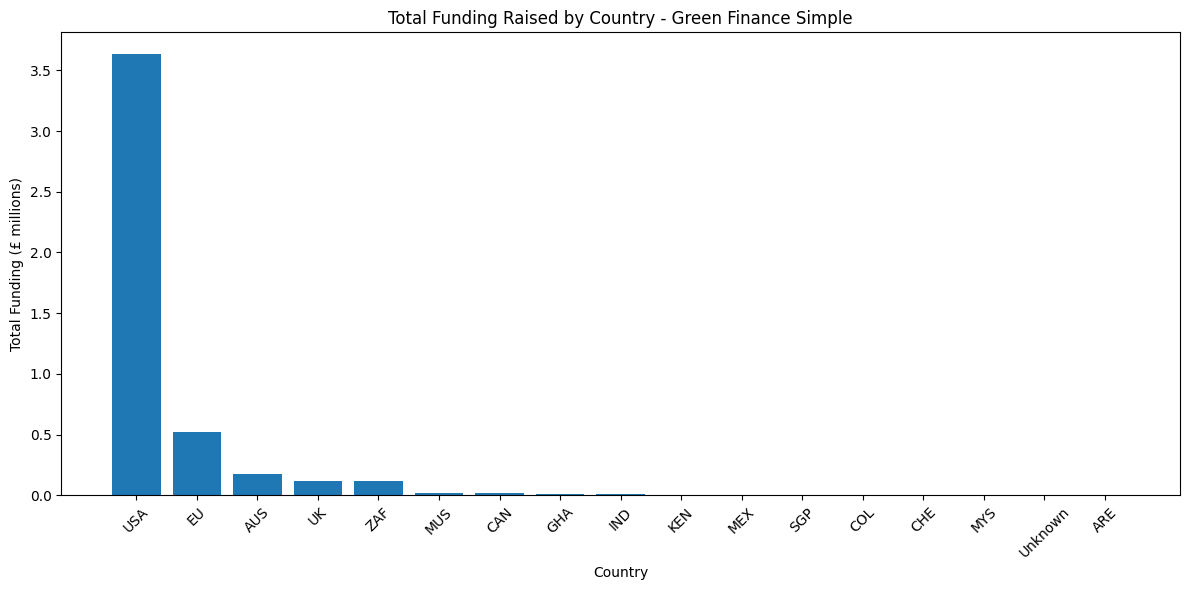

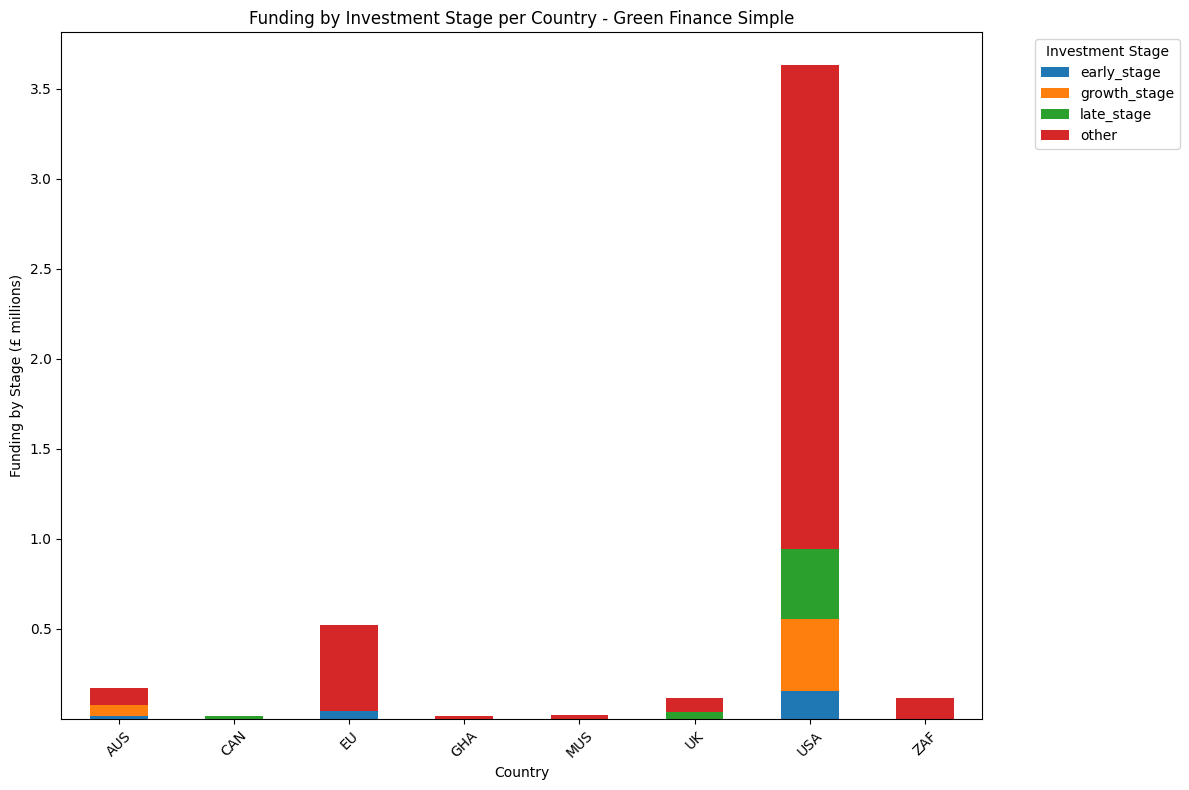

\nFunding Summary for green_finance_simple:
Total funding across all countries: £4.6M
Number of countries with funding: 17
\nTop 5 countries by funding:
  USA: £3.6M (88 rounds)
  EU: £0.5M (15 rounds)
  AUS: £0.2M (10 rounds)
  UK: £0.1M (6 rounds)
  ZAF: £0.1M (2 rounds)
\nInvestment stage breakdown across all countries:
  other: £3.5M
  growth_stage: £0.5M
  late_stage: £0.5M
  early_stage: £0.2M
\n📄 Chart data exported to: /Users/karlis.kanders/Code/discovery_mission_radar/data/green_finance/cb/green_finance_simple/produce_stats/chart_csvs
=== Enhanced Country Analysis for low_carbon_heating ===


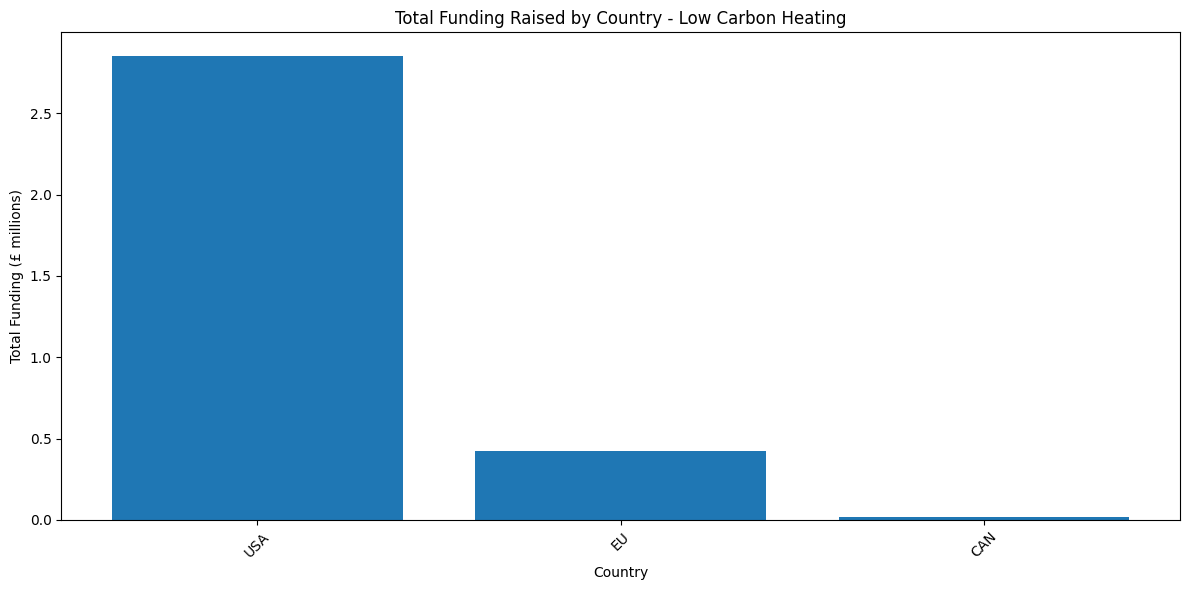

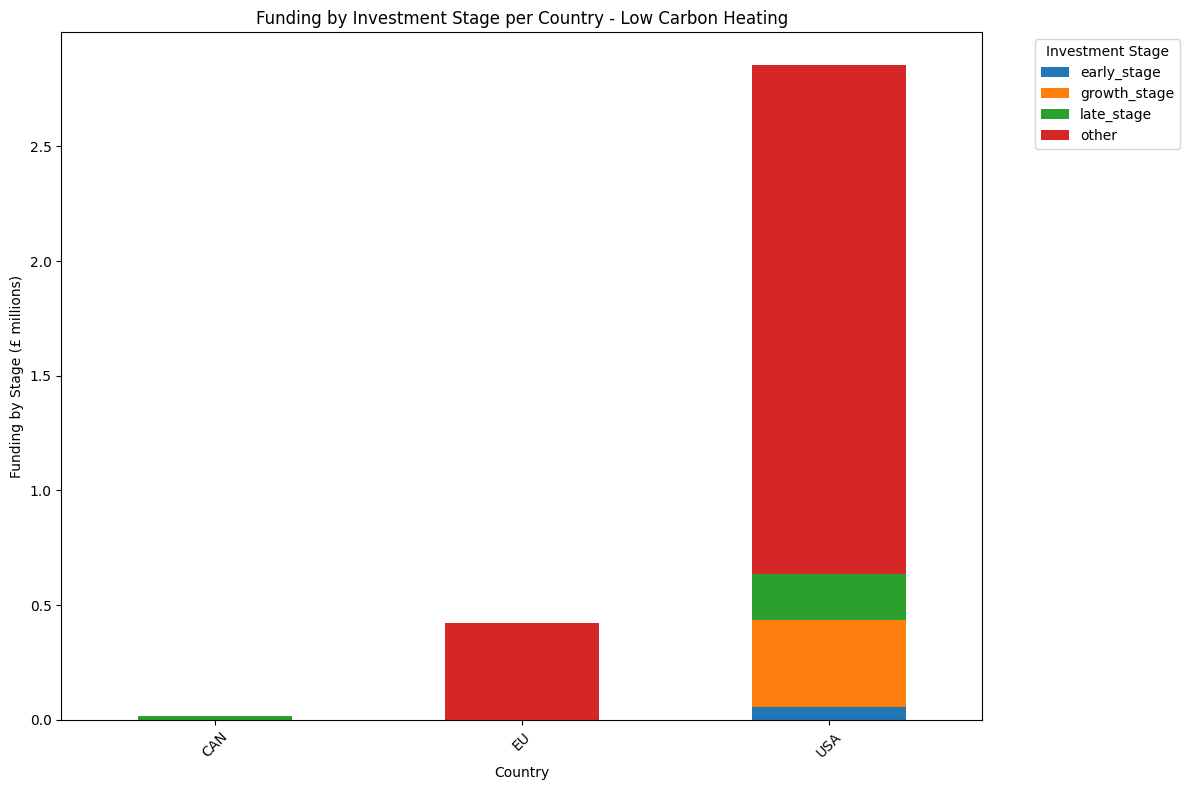

\nFunding Summary for low_carbon_heating:
Total funding across all countries: £3.3M
Number of countries with funding: 3
\nTop 5 countries by funding:
  USA: £2.9M (44 rounds)
  EU: £0.4M (2 rounds)
  CAN: £0.0M (1 rounds)
\nInvestment stage breakdown across all countries:
  other: £2.6M
  growth_stage: £0.4M
  late_stage: £0.2M
  early_stage: £0.1M
\n📄 Chart data exported to: /Users/karlis.kanders/Code/discovery_mission_radar/data/green_finance/cb/low_carbon_heating/produce_stats/chart_csvs


In [16]:
import matplotlib.pyplot as plt

# List of EU country codes (ISO Alpha-3)
eu_countries = {
    'AUT', 'BEL', 'BGR', 'HRV', 'CYP', 'CZE', 'DNK', 'EST', 'FIN', 'FRA', 'DEU', 'GRC', 'HUN',
    'IRL', 'ITA', 'LVA', 'LTU', 'LUX', 'MLT', 'NLD', 'POL', 'PRT', 'ROU', 'SVK', 'SVN', 'ESP', 'SWE'
}

# Function to map country codes
def map_country(code):
    if code == 'GBR':
        return 'UK'
    elif code in eu_countries:
        return 'EU'
    elif pd.isna(code):
        return 'Unknown'
    else:
        return code

# Enhanced geographic analysis for both configs
for config_name in configs:
    print(f"=== Enhanced Country Analysis for {config_name} ===")
    
    # Create directories for this config
    config_charts_dir = OUTPUT_DIR / config_name / "produce_stats" / "charts"
    chart_csvs_dir = OUTPUT_DIR / config_name / "produce_stats" / "chart_csvs"
    config_charts_dir.mkdir(parents=True, exist_ok=True)
    chart_csvs_dir.mkdir(parents=True, exist_ok=True)
    
    # Load the filtered companies CSV for this config from new directory structure
    companies_df = pd.read_csv(OUTPUT_DIR / config_name / "filtered" / f"relevant_{config_name}_llm_filtered.csv")
    
    # Load the funding rounds data from produce_stats
    funding_rounds_df = pd.read_csv(OUTPUT_DIR / config_name / "produce_stats" / "all_funding_rounds_df.csv")
    
    # Add country grouping to funding rounds
    funding_rounds_df['country_grouped'] = funding_rounds_df['country_code'].apply(map_country)
    
    # Add investment stage mapping
    funding_rounds_df['investment_stage'] = funding_rounds_df['investment_type'].map(investment_type_to_stage)
    
    # 1. FUNDING AMOUNTS BY COUNTRY
    country_funding = (
        funding_rounds_df.groupby('country_grouped')
        .agg({
            'raised_amount_gbp': 'sum',
            'funding_round_id': 'count'
        })
        .reset_index()
        .rename(columns={
            'raised_amount_gbp': 'total_funding_gbp',
            'funding_round_id': 'num_funding_rounds'
        })
        .sort_values('total_funding_gbp', ascending=False)
    )
    
    # Convert to millions for readability
    country_funding['total_funding_millions'] = country_funding['total_funding_gbp'] / 1_000_000
    
    # 2. FUNDING BREAKDOWN BY INVESTMENT STAGE PER COUNTRY
    country_stage_breakdown = (
        funding_rounds_df.groupby(['country_grouped', 'investment_stage'])
        .agg({
            'raised_amount_gbp': 'sum',
            'funding_round_id': 'count'
        })
        .reset_index()
        .rename(columns={
            'raised_amount_gbp': 'stage_funding_gbp',
            'funding_round_id': 'stage_funding_rounds'
        })
    )
    
    # Convert to millions
    country_stage_breakdown['stage_funding_millions'] = country_stage_breakdown['stage_funding_gbp'] / 1_000_000
    
    # Save data to CSV (both main data and chart data)
    produce_stats_dir = OUTPUT_DIR / config_name / "produce_stats"
    country_funding.to_csv(produce_stats_dir / f"country_funding_{config_name}.csv", index=False)
    country_stage_breakdown.to_csv(produce_stats_dir / f"country_stage_breakdown_{config_name}.csv", index=False)
    
    # EXPORT CHART DATA AS CSVs
    # 4. Country funding chart data (for bar chart)
    country_funding_chart_data = country_funding[['country_grouped', 'total_funding_millions', 'num_funding_rounds']].copy()
    country_funding_chart_data.to_csv(chart_csvs_dir / f"country_funding_chart_data_{config_name}.csv", index=False)
    
    # 5. Country stage breakdown chart data (for stacked bar chart)
    # Pivot data for easier chart consumption
    stage_pivot_chart_data = country_stage_breakdown.pivot(
        index='country_grouped', 
        columns='investment_stage', 
        values='stage_funding_millions'
    ).fillna(0).reset_index()
    stage_pivot_chart_data.to_csv(chart_csvs_dir / f"country_stage_breakdown_chart_data_{config_name}.csv", index=False)
    
    # Also save the original format for detailed analysis
    country_stage_breakdown.to_csv(chart_csvs_dir / f"country_stage_breakdown_detailed_{config_name}.csv", index=False)
    
    # 3. VISUALIZATIONS
    
    # Chart 1: Total Funding Amounts by Country
    plt.figure(figsize=(12, 6))
    plt.bar(country_funding['country_grouped'], country_funding['total_funding_millions'])
    plt.xlabel("Country")
    plt.ylabel("Total Funding (£ millions)")
    plt.title(f"Total Funding Raised by Country - {config_name.replace('_', ' ').title()}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(config_charts_dir / f"{config_name}_country_funding_amounts.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Chart 2: Funding Breakdown by Investment Stage per Country (Stacked Bar)
    # Pivot data for stacked bar chart
    stage_pivot = country_stage_breakdown.pivot(
        index='country_grouped', 
        columns='investment_stage', 
        values='stage_funding_millions'
    ).fillna(0)
    
    # Only show countries with significant funding (top countries from country_funding)
    top_countries = country_funding.head(8)['country_grouped'].tolist()
    stage_pivot_filtered = stage_pivot.loc[stage_pivot.index.isin(top_countries)]
    
    plt.figure(figsize=(12, 8))
    stage_pivot_filtered.plot(kind='bar', stacked=True, ax=plt.gca())
    plt.xlabel("Country")
    plt.ylabel("Funding by Stage (£ millions)")
    plt.title(f"Funding by Investment Stage per Country - {config_name.replace('_', ' ').title()}")
    plt.legend(title="Investment Stage", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(config_charts_dir / f"{config_name}_country_stage_breakdown.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary statistics
    print(f"\\nFunding Summary for {config_name}:")
    print(f"Total funding across all countries: £{country_funding['total_funding_gbp'].sum()/1_000_000:.1f}M")
    print(f"Number of countries with funding: {len(country_funding)}")
    print("\\nTop 5 countries by funding:")
    for _, row in country_funding.head(5).iterrows():
        print(f"  {row['country_grouped']}: £{row['total_funding_millions']:.1f}M ({row['num_funding_rounds']} rounds)")
    
    print("\\nInvestment stage breakdown across all countries:")
    stage_totals = country_stage_breakdown.groupby('investment_stage')['stage_funding_gbp'].sum() / 1_000_000
    for stage, amount in stage_totals.sort_values(ascending=False).items():
        print(f"  {stage}: £{amount:.1f}M")
    
    print(f"\\n📄 Chart data exported to: {chart_csvs_dir}")
    print("=" * 60)

## 5. Google Sheets Upload

Upload the generated CSV data to Google Sheets for easy sharing and further analysis.

In [17]:
# Google Sheets Upload Configuration - MAIN DATA ONLY
from discovery_utils.utils import google
from discovery_utils.getters import crunchbase

# Set your Google Sheet IDs here - one for each config
sheet_ids = {
    "green_finance_simple": "1obUnzO6GQ7eiVvXxpK4yHs7u2nr4p8zMSCFCULHcHVY",  # Replace with your Green Finance Google Sheet ID
    "low_carbon_heating": "1-BlX8MNJ9mkFWBw9_sxaK-9IkkFQBqj0PCfojzw1mJY"  # Replace with your Low Carbon Heating Google Sheet ID
}

# Optionally specify a single sheet to update (e.g. "llm_filtered_companies"); set to None to update all MAIN DATA
SHEET_TO_UPDATE = None  # Set to specific sheet name to update only that sheet

# Process and upload MAIN DATA for each config to its respective sheet
for config_name in configs:
    print(f"Processing {config_name} for Google Sheets upload (MAIN DATA ONLY)...")
    
    # Get the sheet ID for this config
    sheet_id = sheet_ids[config_name]
    
    # Load the CSV files for this config from new directory structure
    config_output_dir = CB_OUTPUT_DIR / config_name
    produce_stats_dir = config_output_dir / "produce_stats"
    
    try:
        # Read the main data files from produce_stats directory
        all_ts_df = pd.read_csv(produce_stats_dir / "all_ts_df.csv")
        all_growth_rates = pd.read_csv(produce_stats_dir / "all_growth_rates.csv") 
        all_ipos_df = pd.read_csv(produce_stats_dir / "all_ipos_df.csv")
        all_acquisitions_df = pd.read_csv(produce_stats_dir / "all_acquisitions_df.csv")
        all_funding_rounds_df = pd.read_csv(produce_stats_dir / "all_funding_rounds_df.csv")
        all_orgs = pd.read_csv(produce_stats_dir / "all_orgs.csv")
        
        # Load relevant data from raw and filtered directories to get ai_relevance_check
        relevant_df = pd.read_csv(config_output_dir / "raw" / f"relevant_{config_name}.csv")
        relevant_check_df = pd.read_json(config_output_dir / "raw" / f"llm_check_MS_{config_name}.jsonl", lines=True)
        
        # Merge to get the ai_relevance_check column
        relevant_checked_df = relevant_df.merge(
            relevant_check_df[['id', 'is_relevant']], on='id', how='left'
        )
        
        # Process funding rounds data similar to reference code
        _all_funding_rounds_df = (
            all_funding_rounds_df
            .assign(investment_stage = lambda df: df.investment_type.map(crunchbase.investment_type_to_stage()))
            .assign(region_nesta = lambda df: df.country_code.map(crunchbase.country_to_region()))
        )[cols_funding_rounds]
        
        # Process organizations data - properly handle the merge and rename
        print(f"  - Raw data columns: {len(relevant_checked_df.columns)} columns")
        
        # Create the processed organizations dataframe with proper renaming
        _all_orgs = (
            relevant_checked_df
            .rename(columns={
                'category': 'landscape_category', 
                'keyword_cluster': 'landscape_keyword_cluster', 
                "is_relevant": "ai_relevance_check"  # This is the key rename
            })
            .assign(region_nesta = lambda df: df.country_code.map(crunchbase.country_to_region()))
            .assign(theme=config_name)  # Add theme column
        )
        
        print(f"  - After processing: {len(_all_orgs.columns)} columns")
        print(f"  - Has ai_relevance_check: {'ai_relevance_check' in _all_orgs.columns}")
        print(f"  - Has theme: {'theme' in _all_orgs.columns}")
        
        # Only select columns that actually exist in the dataframe
        available_cols = [col for col in cols_companies if col in _all_orgs.columns]
        missing_cols = [col for col in cols_companies if col not in _all_orgs.columns]
        
        if missing_cols:
            print(f"  - Warning: Missing columns will be skipped: {missing_cols}")
        
        print(f"  - Will select {len(available_cols)} columns out of {len(cols_companies)} requested")
        
        _all_orgs = _all_orgs[available_cols]
        
        # ALSO export only the LLM-approved rows
        _llm_only = _all_orgs.query("ai_relevance_check == 'yes'").copy()
        
        print(f"  - Companies: {len(_all_orgs)} (pre-LLM), {len(_llm_only)} (LLM-approved)")
        print(f"Data prepared for {config_name}:")
        print(f"  - Companies: {len(_all_orgs)}")
        print(f"  - Funding rounds: {len(_all_funding_rounds_df)}")
        print(f"  - IPOs: {len(all_ipos_df)}")
        print(f"  - Acquisitions: {len(all_acquisitions_df)}")
        
        # Upload MAIN DATA ONLY to Google Sheets 
        sheet_names = {
            "crunchbase_companies": _all_orgs,
            "llm_filtered_companies": _llm_only,
            "crunchbase_funding": _all_funding_rounds_df,
            "crunchbase_acquisitions": all_acquisitions_df,
            "crunchbase_ipos": all_ipos_df,
            "crunchbase_timeseries": all_ts_df,
            "crunchbase_growth_rates": all_growth_rates,
        }
        
        # Only upload non-empty dataframes (and optionally limit to one sheet)
        if SHEET_TO_UPDATE:
            upload_data = {name: df for name, df in sheet_names.items()
                           if name == SHEET_TO_UPDATE and not df.empty}
        else:
            upload_data = {name: df for name, df in sheet_names.items() 
                          if not df.empty and len(df.columns) > 0}
        
        print(f"  - Preparing to upload {len(upload_data)} MAIN DATA sheets")
        
        if upload_data:
            google.upload_data_to_gsheet(sheet_id, upload_data)
            print(f"✓ Uploaded {len(upload_data)} MAIN DATA sheets for {config_name} to Google Sheet: {sheet_id}")
            
            # Apply formatting to key sheets with error handling
            try:
                google.format_gsheet(sheet_id, "crunchbase_companies", freeze_cols=4)
                google.format_gsheet(sheet_id, "crunchbase_funding", freeze_cols=2)
                        
            except Exception as e:
                print(f"  - Warning: Could not apply formatting: {e}")
            
        else:
            print(f"⚠️  No data to upload for {config_name}")
            
    except FileNotFoundError as e:
        print(f"⚠️  Could not find data files for {config_name}: {e}")
        print("Make sure you've run the analysis sections above first.")
    except Exception as e:
        print(f"❌ Error uploading {config_name} to Google Sheets: {e}")
        import traceback
        traceback.print_exc()

print("\\n🎯 Main data Google Sheets upload complete!")

Processing green_finance_simple for Google Sheets upload (MAIN DATA ONLY)...
  - Raw data columns: 63 columns
  - After processing: 65 columns
  - Has ai_relevance_check: True
  - Has theme: True
  - Will select 37 columns out of 37 requested
  - Companies: 634 (pre-LLM), 172 (LLM-approved)
Data prepared for green_finance_simple:
  - Companies: 634
  - Funding rounds: 157
  - IPOs: 1
  - Acquisitions: 11
  - Preparing to upload 7 MAIN DATA sheets
2025-07-31 15:47:51,233 - root - INFO - Connected to Google Sheet: CB Green Finance
2025-07-31 15:47:52,589 - root - INFO - Uploading DataFrame to sheet: crunchbase_companies


/Users/karlis.kanders/Code/discovery_mission_radar/.venv/lib/python3.12/site-packages/df2gspread/df2gspread.py:138: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(str)
/Users/karlis.kanders/Code/discovery_mission_radar/.venv/lib/python3.12/site-packages/df2gspread/df2gspread.py:138: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(str)


2025-07-31 15:48:12,619 - root - INFO - Connected to Google Sheet: CB Green Finance
2025-07-31 15:48:13,876 - root - INFO - Uploading DataFrame to sheet: llm_filtered_companies


/Users/karlis.kanders/Code/discovery_mission_radar/.venv/lib/python3.12/site-packages/df2gspread/df2gspread.py:138: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(str)
/Users/karlis.kanders/Code/discovery_mission_radar/.venv/lib/python3.12/site-packages/df2gspread/df2gspread.py:138: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(str)


2025-07-31 15:48:29,774 - root - INFO - Connected to Google Sheet: CB Green Finance
2025-07-31 15:48:31,548 - root - INFO - Uploading DataFrame to sheet: crunchbase_funding


...

2025-07-31 15:51:08,888 - root - INFO - Connected to Google Sheet: CB LCH green finance
2025-07-31 15:51:09,602 - root - INFO - Uploading DataFrame to sheet: crunchbase_timeseries


/Users/karlis.kanders/Code/discovery_mission_radar/.venv/lib/python3.12/site-packages/df2gspread/df2gspread.py:138: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(str)
/Users/karlis.kanders/Code/discovery_mission_radar/.venv/lib/python3.12/site-packages/df2gspread/df2gspread.py:138: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(str)


2025-07-31 15:51:21,240 - root - INFO - Connected to Google Sheet: CB LCH green finance
2025-07-31 15:51:22,457 - root - INFO - Uploading DataFrame to sheet: crunchbase_growth_rates


/Users/karlis.kanders/Code/discovery_mission_radar/.venv/lib/python3.12/site-packages/df2gspread/df2gspread.py:138: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(str)
/Users/karlis.kanders/Code/discovery_mission_radar/.venv/lib/python3.12/site-packages/df2gspread/df2gspread.py:138: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(str)


2025-07-31 15:51:30,975 - root - INFO - Upload completed successfully.
✓ Uploaded 7 MAIN DATA sheets for low_carbon_heating to Google Sheet: 1-BlX8MNJ9mkFWBw9_sxaK-9IkkFQBqj0PCfojzw1mJY
2025-07-31 15:51:31,589 - root - INFO - Connected to Google Sheet: CB LCH green finance
2025-07-31 15:51:35,251 - root - INFO - Connected to Google Sheet: CB LCH green finance
\n🎯 Main data Google Sheets upload complete!


In [20]:
# Google Sheets Upload - CHART DATA ONLY
# Run this cell separately to upload just the chart data when needed

# Use the same sheet IDs as above
chart_sheet_ids = {
    "green_finance_simple": "1obUnzO6GQ7eiVvXxpK4yHs7u2nr4p8zMSCFCULHcHVY",
    "low_carbon_heating": "1-BlX8MNJ9mkFWBw9_sxaK-9IkkFQBqj0PCfojzw1mJY"
}

# Optionally specify a single chart to update, or None for all charts
CHART_TO_UPDATE = None  # e.g. "chart_timeseries" or None for all

print("🔥 Starting CHART DATA upload...")

# Process and upload CHART DATA for each config
for config_name in configs:
    print(f"Processing {config_name} for Chart Data upload...")
    
    # Get the sheet ID for this config
    sheet_id = chart_sheet_ids[config_name]
    
    # Load chart CSV data files
    config_output_dir = CB_OUTPUT_DIR / config_name
    produce_stats_dir = config_output_dir / "produce_stats"
    chart_csvs_dir = produce_stats_dir / "chart_csvs"
    
    try:
        chart_data = {}
        chart_files = {
            "chart_timeseries": f"time_series_chart_data_{config_name}.csv",
            "chart_investment_types": f"investment_types_chart_data_{config_name}.csv", 
            "chart_investment_stages": f"investment_stages_chart_data_{config_name}.csv",
            "chart_country_funding": f"country_funding_chart_data_{config_name}.csv",
            "chart_country_stages": f"country_stage_breakdown_chart_data_{config_name}.csv"
        }
        
        # Load chart data with error handling
        for tab_name, filename in chart_files.items():
            chart_file_path = chart_csvs_dir / filename
            if chart_file_path.exists():
                try:
                    chart_df = pd.read_csv(chart_file_path)
                    if not chart_df.empty:
                        chart_data[tab_name] = chart_df
                        print(f"  ✓ Loaded {tab_name}: {len(chart_df)} rows")
                    else:
                        print(f"  ⚠️  Chart file is empty: {filename}")
                except Exception as e:
                    print(f"  ❌ Error loading chart file {filename}: {e}")
            else:
                print(f"  ⚠️  Chart file not found: {filename}")
        
        # Filter to specific chart if requested
        if CHART_TO_UPDATE:
            if CHART_TO_UPDATE in chart_data:
                chart_data = {CHART_TO_UPDATE: chart_data[CHART_TO_UPDATE]}
                print(f"  - Uploading only: {CHART_TO_UPDATE}")
            else:
                print(f"  ⚠️  Requested chart {CHART_TO_UPDATE} not found")
                continue
        
        print(f"  - Chart datasets ready: {len(chart_data)}")
        
        if chart_data:
            # Upload chart data to Google Sheets
            google.upload_data_to_gsheet(sheet_id, chart_data)
            print(f"✓ Uploaded {len(chart_data)} CHART sheets for {config_name} to Google Sheet: {sheet_id}")
            
            # Apply formatting to chart sheets
            try:
                for chart_tab in chart_data.keys():
                    google.format_gsheet(sheet_id, chart_tab, freeze_cols=1)
                print(f"  ✓ Applied formatting to {len(chart_data)} chart sheets")
                        
            except Exception as e:
                print(f"  - Warning: Could not apply formatting to charts: {e}")
            
        else:
            print(f"⚠️  No chart data to upload for {config_name}")
            
    except Exception as e:
        print(f"❌ Error uploading chart data for {config_name}: {e}")
        import traceback
        traceback.print_exc()

print("\\n🎯 Chart data Google Sheets upload complete!")

🔥 Starting CHART DATA upload...
Processing green_finance_simple for Chart Data upload...
  ✓ Loaded chart_timeseries: 12 rows
  ✓ Loaded chart_investment_types: 96 rows
  ✓ Loaded chart_investment_stages: 48 rows
  ✓ Loaded chart_country_funding: 17 rows
  ✓ Loaded chart_country_stages: 17 rows
  - Chart datasets ready: 5
2025-07-31 16:00:39,915 - root - INFO - Connected to Google Sheet: CB Green Finance
2025-07-31 16:00:41,742 - root - INFO - Uploading DataFrame to sheet: chart_timeseries


/Users/karlis.kanders/Code/discovery_mission_radar/.venv/lib/python3.12/site-packages/df2gspread/df2gspread.py:138: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(str)
/Users/karlis.kanders/Code/discovery_mission_radar/.venv/lib/python3.12/site-packages/df2gspread/df2gspread.py:138: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(str)


2025-07-31 16:00:59,784 - root - INFO - Connected to Google Sheet: CB Green Finance
2025-07-31 16:01:01,575 - root - INFO - Uploading DataFrame to sheet: chart_investment_types


/Users/karlis.kanders/Code/discovery_mission_radar/.venv/lib/python3.12/site-packages/df2gspread/df2gspread.py:138: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(str)
/Users/karlis.kanders/Code/discovery_mission_radar/.venv/lib/python3.12/site-packages/df2gspread/df2gspread.py:138: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(str)


2025-07-31 16:01:16,652 - root - INFO - Connected to Google Sheet: CB Green Finance
2025-07-31 16:01:17,870 - root - INFO - Uploading DataFrame to sheet: chart_investment_stages


...

2025-07-31 16:03:11,046 - root - INFO - Connected to Google Sheet: CB LCH green finance
2025-07-31 16:03:12,248 - root - INFO - Uploading DataFrame to sheet: chart_country_funding


/Users/karlis.kanders/Code/discovery_mission_radar/.venv/lib/python3.12/site-packages/df2gspread/df2gspread.py:138: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(str)
/Users/karlis.kanders/Code/discovery_mission_radar/.venv/lib/python3.12/site-packages/df2gspread/df2gspread.py:138: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(str)


2025-07-31 16:03:24,276 - root - INFO - Connected to Google Sheet: CB LCH green finance
2025-07-31 16:03:25,391 - root - INFO - Uploading DataFrame to sheet: chart_country_stages


/Users/karlis.kanders/Code/discovery_mission_radar/.venv/lib/python3.12/site-packages/df2gspread/df2gspread.py:138: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(str)
/Users/karlis.kanders/Code/discovery_mission_radar/.venv/lib/python3.12/site-packages/df2gspread/df2gspread.py:138: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(str)


2025-07-31 16:03:36,234 - root - INFO - Upload completed successfully.
✓ Uploaded 5 CHART sheets for low_carbon_heating to Google Sheet: 1-BlX8MNJ9mkFWBw9_sxaK-9IkkFQBqj0PCfojzw1mJY
2025-07-31 16:03:37,274 - root - INFO - Connected to Google Sheet: CB LCH green finance
2025-07-31 16:03:40,799 - root - INFO - Connected to Google Sheet: CB LCH green finance
2025-07-31 16:03:43,942 - root - INFO - Connected to Google Sheet: CB LCH green finance
2025-07-31 16:03:47,583 - root - INFO - Connected to Google Sheet: CB LCH green finance
2025-07-31 16:03:51,565 - root - INFO - Connected to Google Sheet: CB LCH green finance
  ✓ Applied formatting to 5 chart sheets
\n🎯 Chart data Google Sheets upload complete!


---

## 🔧 Troubleshooting

### Common Issues

**1. Missing Configuration Files**
```
Error: FileNotFoundError: config_green_finance_simple.yaml
Solution: Ensure YAML config files exist in config/ directory
```

**2. LLM Processing Timeouts**  
```
Error: LLM batch processing timeout
Solution: Reduce batch_size from 15 to 10, increase sleep_time to 1.0
```

**3. Google Sheets Upload Failures**
```
Error: 403 Insufficient permissions  
Solution: Verify service account has edit access to target sheets
```

**4. Memory Issues**
```
Error: MemoryError during analysis
Solution: Process configs individually, restart kernel between runs
```

### Data Quality Validation

Expected results after filtering:
- **Green Finance Simple**: 100-200 companies
- **Low Carbon Heating**: 15-30 companies  
- **Filtering ratio**: 10-25% of green finance companies should be heating-focused

If results are significantly outside these ranges, check:
- Search term configuration in YAML files
- SCORE_THRESHOLD setting (try 0.2-0.4 range)
- LLM relevance checking logic

### Performance Tips

- **For development**: Set `SHEET_TO_UPDATE` to process single sheets
- **For memory**: Clear large variables with `del variable_name` between sections
- **For speed**: Use existing filtered data when possible (don't delete filtered/ dirs)
- **For debugging**: Check intermediate CSV files in raw/ directories